
# EMPIRICAL ANALYSIS OF BITCOIN LOG-RETURNS

This notebook presents an empirical analysis of Bitcoin daily log-returns, focusing on their statistical properties and deviations from the Gaussian model. We examine the distribution's shape, kurtosis, heavy tails, temporal dependence, and scaling behavior. Through visualizations and quantitative metrics, we explore volatility clustering, extreme events, and the presence of long-term memory in absolute returns. The study highlights key differences between real-world financial data and standard assumptions of normality, providing insights into the complex dynamics of cryptocurrency markets.

# Table of Contents

1. [Python Libraries](#1-python-libraries)
2. [Data and methodology](#2-data-and-methodology)
   - [Data Source and cleaning](#21-data-source-and-cleaning)
   - [Definition of Log-Returns](#22-definition-of-log-returns)
3. [Exploratory Analysis of Returns](#3-exploratory-analysis-of-returns)
   - [Time Series of Log-Returns](#31-time-series-of-log-returns)
   - [Distribution Overview](#32-distribution-overview)
4. [Comparison with the Gaussian Model](#4-comparison-with-the-gaussian-model)
   - [Histogram vs Normal Distribution](#41-histogram-vs-normal-distribution)
   - [Q-Q Plot Against Normal](#42-extreme-event-frequency)
   - [Extreme Event Frequency](#43-q-q-plot-against-normal)
5. [Kurtosis and Temporal Aggregation](#5-kurtosis-and-temporal-aggregation)
   - [Kurtosis](#51-daily-kurtosis)
   - [Kurtosis Across Time Horizons](#52-kurtosis-across-time-horizons)
6. [Heavy Tails Analysis](#6-heavy-tails-analysis)
   - [Tail Distribution (Log-Log Plot)](#61-tail-distribution-log-log-plot)
   - [Tail Exponent Estimation](#62-tail-exponent-estimation)
7. [Temporal Dependence](#7-temporal-dependence)
   - [Autocorrelation of Returns](#71-autocorrelation-of-returns)
   - [Autocorrelation of Squared/Absolute Returns](#72-autocorrelation-of-squared-returns)
8. [Scaling Behavior](#8-scaling-behavior)
   - [Hurst Exponent for Returns](#81-hurst-exponent-for-returns)
   - [Hurst Exponent for Absolute Returns](#82-hurst-exponent-for-absolute-returns)
9. [Summary of Empirical Findings and Implications](#9-summary-of-empirical-findings-and-implications)
10. [Discussion of Limitations and Potential Extensions](#10-discussion-of-limitations-and-potential-extensions)
11. [References](#11-references)


## 1. Python Libraries



- **yfinance** to obtain historical Bitcoin prices.
- **pandas** for manipulating time series data.
- **numpy** for numerical processing and logarithmic transformations.
- **matplotlib** for technical visualization of time series and distributions.
- **scipy** for performing statistical tests.
- **statsmodels** for building regressions.

From the `scipy.stats` y `statsmodels` libraries, it is recommended to import only the functions `norm`, `plot_acf` and `linregress`.

In [2]:
import yfinance as yf 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  #only pyplot module


from scipy.stats import norm #for normal distributed random variables
from statsmodels.graphics.tsaplots import plot_acf #for visualizing autocorrelation 
from scipy.stats import linregress #for lineal regressions 
from scipy.stats import probplot #for Q-Q plot 

## 2. Data and Methodology 



### 2.1 Data Source and cleaning 
 
The data is obtained directly from Yahoo Finance using the ``yfinance`` library. Throughout the project we will work with **daily closing prices**, and the time interval studied spans from the earliest available record up to the present day. Since Bitcoin trades 24/7, the closing price is taken at 00:00 UTC.

> Only in Section 5.2 will we consider time intervals longer than one day.

In [3]:
btc = yf.download("BTC-USD", period = "max", interval = "1d")
prices = btc["Close"]
prices = prices.dropna() #para asegurar que no hay ningún valor faltante NaN

[*********************100%***********************]  1 of 1 completed


### 2.2 Definition of Log-Returns 

We use daily returns in order to maximize the sample size and because, at this time scale, the heavy-tail structure of financial returns is known to be particularly visible. Returns are constructed in logarithmic scale using the expression:

$$r_t = ln\left(\frac{P_{t+1}}{P_t}\right)$$

Using **log-returns** ensures additivity over time and provides better statistical properties for analysis.

In [4]:

returns = np.log(prices).diff() #método optimizado para series temporales
returns = returns.dropna() #para asegurar que no hay ningún valor faltante NaN

## 3. Exploratory Analysis of Returns

Before proceeding with the statistical analysis of returns, we first present two graphical representations in order to obtain an initial visual perspective of the data and the main features that will be examined later.

### 3.1 Time Series of Log-Returns

First, we plot the daily log-returns as a function of time in order to obtain an initial view of the possible temporal dependence present in the series.

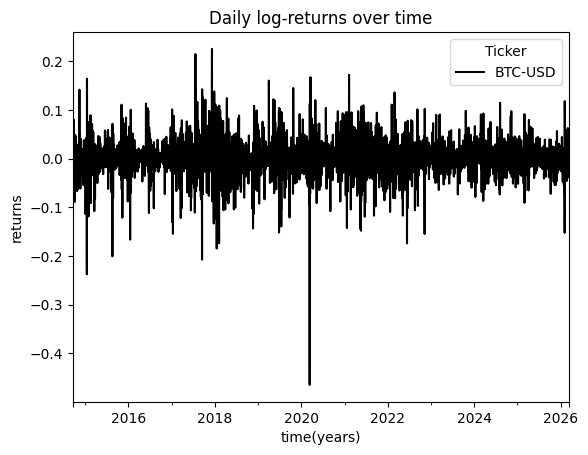

In [5]:
fig, ax = plt.subplots()

returns.plot(ax=ax, color="black")
ax.set_title("Daily log-returns over time")
ax.set_xlabel("time(years)")
ax.set_ylabel("returns");

A simple visual inspection of the daily log-returns already reveals signs of **volatility clustering**. Returns are not homogeneously distributed over time, instead, there are distinct periods where large fluctuations cluster together, alternating with periods of relatively low volatility.

From the very beginning of the analysis, this suggests that volatility **may depend on the specific moment in time**, rather than remaining constant throughout the series.

### 3.2 Distribution Overview

On the other hand, the box plot representation provides a clear view of how the data is distributed in terms of frequency. The central box is bounded by the first and third quartiles, while the whiskers represent values that extend beyond this interquartile range.

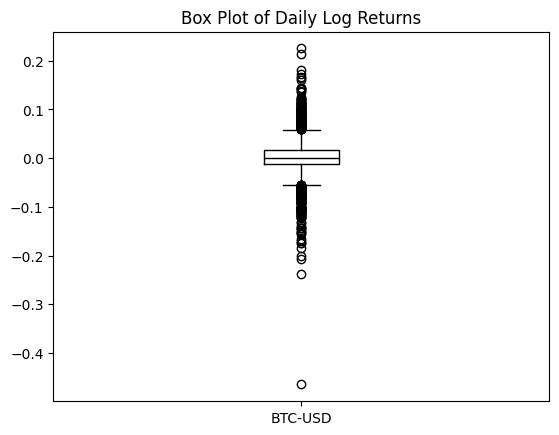

In [6]:
fig, ax = plt.subplots()
returns.plot(ax=ax, color= "black", kind="box")
ax.set_title("Box Plot of Daily Log Returns")

plt.show()

Long whiskers can be observed, which suggests the presence of a significant number of **outliers**. This is closely related to the emergence of heavy tails, a feature that will be examined in more detail later in the analysis.   

## 4. Comparison with the Gaussian Model

Once we have a general idea of the structure of the data and preliminary evidence suggesting that the distribution is not Gaussian, we can now examine how large the difference is between the empirical return distribution and the Gaussian model.


### 4.1 Histogram vs Normal Distribution

We generate a Gaussian distribution with mean $\mu$ and standard deviation $\sigma$ identical to those of the empirical distribution. This Gaussian distribution, shown as the **red line**, is then graphically compared with the **histogram of the empirical returns**.

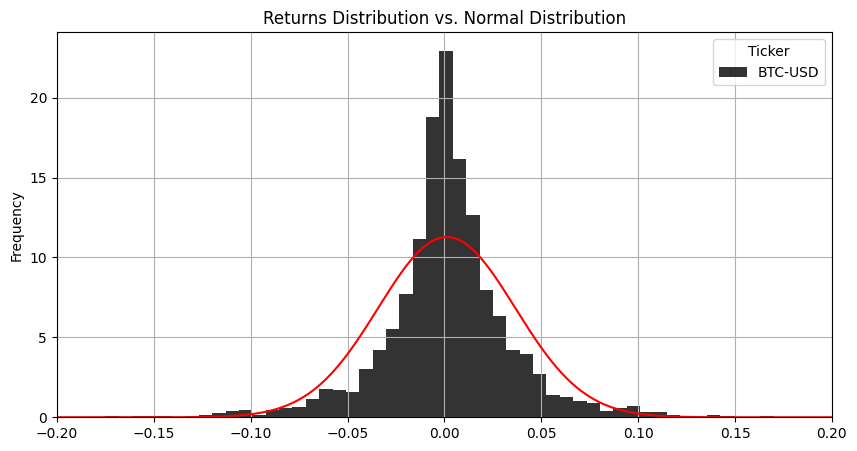

In [7]:
mu = returns.mean() 
sigma = returns.std() 
 
x = np.linspace(-0.25,0.25,1000)
y = norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(x,y, color="red") #gaussian distribution plot
returns.plot(ax=ax, color= "black", kind="hist", bins= 100, alpha= 0.8, density= True) #histogram plot
ax.set_title("Returns Distribution vs. Normal Distribution")
ax.set_xlim(-0.2, 0.2)
ax.grid(True)

plt.show()

If we examine the resulting plot, we can clearly see that the empirical distribution is **much more peaked at the center and thicker in the tails** than the Gaussian distribution. This is consistent with the well-known fact that approximating the returns of real financial assets with a Gaussian model can be highly misleading: the normal distribution underestimates the number of calm days and significantly underestimates the frequency of **extreme events**.

We will analyze the tails of this distribution in more detail later, although it is already evident that **the data exhibits heavy-tailed behavior**.

### 4.2 Extreme Event Frequency

Building on this idea, we can examine more clearly what we mean when we say that the Gaussian model underestimates the number of extreme events. To do this, we calculate the probability that an observation exceeds a given number of standard deviations in both the empirical distribution and the Gaussian distribution.

> For convenience, the empirical distribution has been **rescaled** so that it can be compared with a Gaussian distribution with mean 0 and standard deviation 1.

In [8]:
returns_norm = (returns - mu)/sigma #Estandarización de la distribución de retornos 

sigmas = [2,3,4]
for i in sigmas: 
    prob =  100*np.mean((returns_norm < -i) | (returns_norm > i))
    normi = 100*2*norm.cdf(-i) #el factor 2 es porque cdf te da la probabilidad de que ocurra un evento por encima de cierto valor y nosotros también querriamos su simétrico
    print(f"{i}-sigma event probability: {prob:.4f}% vs. {normi:.4f}% (Gaussian)")

2-sigma event probability: 5.6019% vs. 4.5500% (Gaussian)
3-sigma event probability: 1.8117% vs. 0.2700% (Gaussian)
4-sigma event probability: 0.6198% vs. 0.0063% (Gaussian)


It can be clearly observed that as we move further away from the mean, the difference between the Gaussian probability and the empirical return probability becomes increasingly larger. Not only does this gap widen, but the rate at which it grows is also significant. While the probabilities are relatively similar for events around 2 standard deviations, the difference reaches about **two orders of magnitude when comparing 4-sigma events**.

### 4.3 Q-Q Plot against Normal

Another way to assess whether the data approximately follows a normal distribution is to compare the **observed quantiles** (obtained by ordering the returns from smallest to largest) with the theoretical quantiles of a Gaussian distribution. 

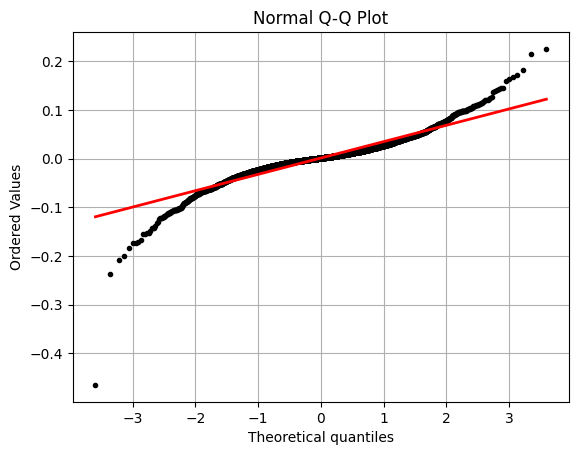

In [9]:
returns_nd = returns["BTC-USD"]

fig, ax = plt.subplots()
probplot(returns_nd, dist="norm", fit= True, plot=ax)
ax.get_lines()[0].set_color("black")   
ax.get_lines()[1].set_color("red")
ax.get_lines()[1].set_linewidth(2)
ax.get_lines()[0].set_markersize(3)
ax.set_title("Normal Q-Q Plot")
ax.grid(True)

plt.show()

As expected, we observe the same pattern seen previously: the points corresponding to the empirical distribution (shown as black dots) deviate from the Gaussian distribution (red line), particularly at the extremes of the distribution. This occurs because **extreme events in the return series are much more probable** than what the Gaussian model predicts. 

## 5. Kurtosis and Temporal Aggregation

In addition to the graphical evidence, we can characterize the distribution in a more analytical way by using **kurtosis**. Formally, kurtosis is defined as the **fourth standardized moment of a distribution**, and it measures how frequent and intense extreme values are relative to the center of the distribution.


### 5.1 Daily Kurtosis

A positive excess kurtosis is characteristic of **leptokurtic distributions**, which are defined by a more pronounced central peak and heavier tails. This is precisely the behavior observed in our case.

For the Gaussian approximation to be considered reasonable, we would expect to obtain an **excess kurtosis close to zero**.

In [10]:
k = returns.kurt()

print(f"Excess kurtosis of daily returns: {k["BTC-USD"]:.2f}")

Excess kurtosis of daily returns: 11.72


It is therefore clear that the excess kurtosis is substantial and clearly **incompatible with a normal distribution**.

### 5.2 Kurtosis Across Time Horizons

We have seen that daily returns deviate significantly from Gaussian behavior, as evidenced by volatility clustering and a large excess kurtosis. However, this observation may change when we consider different time scales, such as weekly or monthly returns.

Using the same procedure described for downloading and calculating daily returns, we compute the excess kurtosis for weekly and monthly returns.

In [11]:
index = ["1d", "1wk", "1mo"]
         
for i in index:     
    btc = yf.download("BTC-USD", period = "max", interval = i)
    prices = btc["Close"]
    returns = np.log(prices/prices.shift(1))
    returns = returns.dropna()
    k = returns.kurt()
    print(f"Excess kurtosis of {i} returns: {k["BTC-USD"]:.4f}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Excess kurtosis of 1d returns: 11.7199
Excess kurtosis of 1wk returns: 1.9592


[*********************100%***********************]  1 of 1 completed

Excess kurtosis of 1mo returns: 0.1883


We observe that as the time scale increases, the excess kurtosis decreases. In other words, the longer the time interval considered, the closer the distribution can be approximated by a normal distribution.

For example, in the case of monthly returns, the Gaussian approximation could be considered reasonable due to the **drastic reduction in kurtosis** at this time scale.

> The result is not surprising: as kurtosis decreases when aggregating returns over longer intervals, this demonstrates the effect of the Central Limit Theorem.

## 6. Heavy Tails Analysis

A more precise way to characterize our distribution is by **quantifying the presence of heavy tails**. In other words, extreme events do not decay exponentially but instead follow a power-law decay of the form:

$$P(∣r∣>x)=Cx^{-α}$$

We use the **absolute value of returns** because, assuming that the tails are roughly symmetric, extreme events on both sides are of equal interest. This approach also allows us to double the number of observations in these already rare regions, improving the robustness of the analysis.


#### 6.1 Tail Distribution (Log-Log Plot)

En primer lugar realizaremos una **log-log plot** donde el eje y será la probabilidad de que un retorno r en valor absoluto sea mayor que cierto retorno r(i), $log(P(∣r∣>r(i)))$, y el eje x será el tamaño del retorno $log(|r|)$. Esta probabilidad acumulada $P(∣r∣>r(i))$ se obtendrá como el número de casos favorables $N-i-1$ entre el número de casos posibles $N$:

First, we create a log–log plot where the y-axis represents the probability that the absolute return $|r|$ exceeds a certain value $r(i)$, $log(P(∣r∣>r(i)))$, and the x-axis represents the size of the return, $log(|r|)$. This **cumulative probability** $P(∣r∣>r(i))$ is calculated as the number of favorable cases $N−i−1$ divided by the total number of observations $N$:

$$P(∣r∣>r(i))=\frac{N-i-1}{N}​$$

Since we do not know exactly where the heavy tail begins, we plot **different percentiles** (90, 95, 99, and 99.5) to check whether at some point the function can be approximated by a straight line.

The advantage of applying logarithms is that the power-law relation is transformed into a straight line:

$$\log P(∣r∣>x)= \log C− \alpha \log x$$

where $-\alpha$ is the slope of the line and corresponds (up to a sign) to the **exponent of the polynomial** approximating the heavy tail.


> It is important to impose the condition $P(∣r∣>r(i)) > 0$ to avoid the indeterminacy of $\log(0)$.  

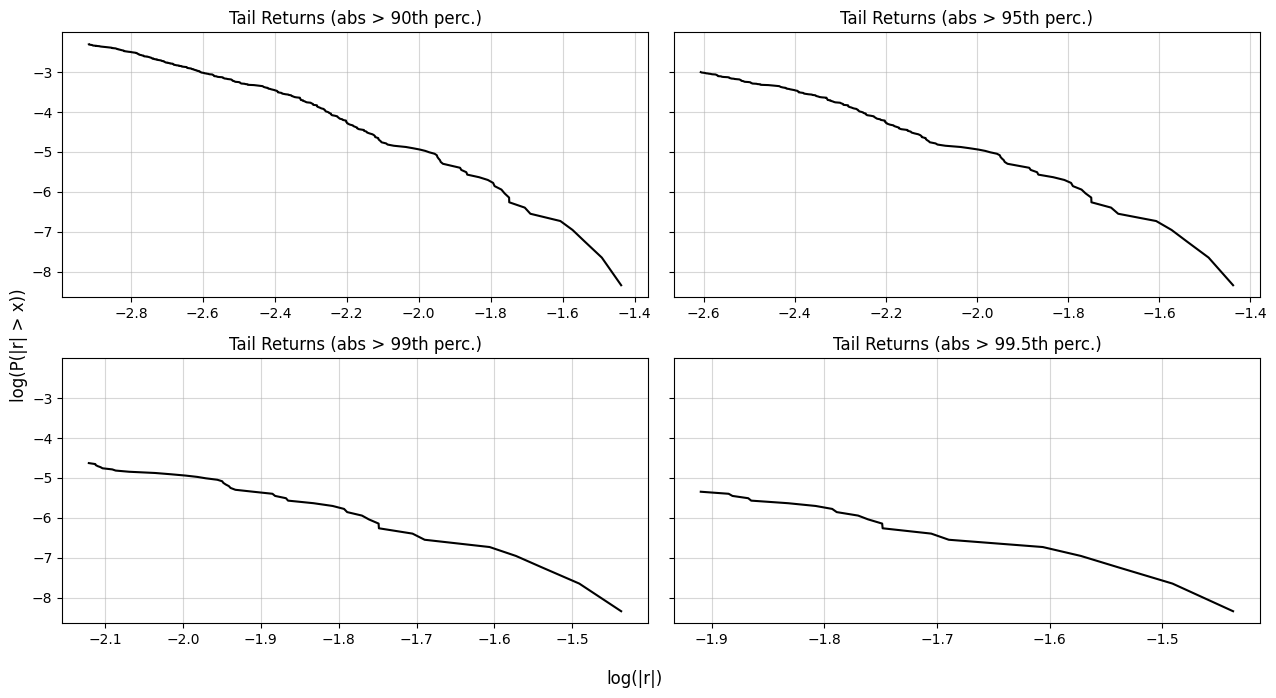

In [12]:

x = np.sort(np.abs(returns_nd)) #generating absolute returns

N = len(x)
y = (N - np.arange(N) - 1) / N 

percentile = [90,95,99,99.5]
index = [0,1,2,3]
fig, ax = plt.subplots(2,2, figsize=(13,7), sharey= True)
ax = ax.flatten()

for i,j in zip(percentile, index): 
     threshold = np.percentile(x, i)
     mask = (x >= threshold) & (y > 0)
     log_x = np.log(x[mask])
     log_y = np.log(y[mask])
     ax[j].plot(log_x, log_y, color="black")
     ax[j].set_title(f"Tail Returns (abs > {i}th perc.)")
     ax[j].grid(True, which="both", alpha=0.5)

fig.supxlabel("log(|r|)")
fig.supylabel("log(P(|r| > x))")
fig.tight_layout()

plt.show()


In none of the four cases do we observe a clearly defined straight line with a consistent slope. This suggests that, although heavy tails are present, they **do not follow a strict power-law behavior**.

### 6.2 Tail Exponent Estimation

This instability of the heavy tails can be quantified by estimating the exponent $\alpha$ which corresponds to the slope of each line in the log–log plot. To do this, we perform a simple linear regression using the ``linregress`` function.

In [13]:
x = np.sort(np.abs(returns_nd))
N = len(x)
y = (N - np.arange(N) - 1) / N 

percentile = [90,95,99,99.5]

for i in percentile: 
     threshold = np.percentile(x, i)
     mask = (x >= threshold) & (y > 0)
     log_x = np.log(x[mask])
     log_y = np.log(y[mask])
     result = linregress(log_x, log_y)
     print(f"Alfa for {i}th percentile: {- result.slope:.4f}")
     print(f"R: {- result.rvalue:.3f}")

Alfa for 90th percentile: 3.1679
R: 0.983
Alfa for 95th percentile: 3.8048
R: 0.987
Alfa for 99th percentile: 4.6954
R: 0.979
Alfa for 99.5th percentile: 5.7802
R: 0.986


First, the fact that our line is not straight in any of the cases translates into moderate $R^2$ values, far from the ideal $R^2 = 0.99$ expected for distributions that perfectly follow a linear function in log–log space. The absence of a strict power-law behavior is evident because the slope (polynomial degree) **does not stabilize at any point**.

Furthermore, the slope would ideally fall between 2 and 4, which suggests that although extreme events do not decay exponentially, they decay relatively quickly for a polynomial-type decay.

> It is important to note that the estimate for the 99.5th percentile is not very reliable, as the number of observations in this region is likely too small to perform a robust linear regression.

## 7. Temporal Dependence

We have analyzed the presence of heavy tails and volatility clustering, but we still need to address the possible autocorrelation of returns, as so far we have treated them as independent. Autocorrelation relates to the idea that temporal dependence (the dependence on the specific point in the historical timeline) can have an impact on returns.

### 7.1 Autocorrelation of Returns

First, we calculate the autocorrelation of returns using the formula:

$$\rho_k​=corr(r_t​, r_{t−k}​)$$

The plot shows the autocorrelation of returns with their own lagged values, where k ranges from 0 to 30. The shaded area represents the region where autocorrelations can still be considered **statistical noise**, with the boundaries given by $\pm \frac{1}{\sqrt{N}}$ where N is the number of observations. 

[*********************100%***********************]  1 of 1 completed


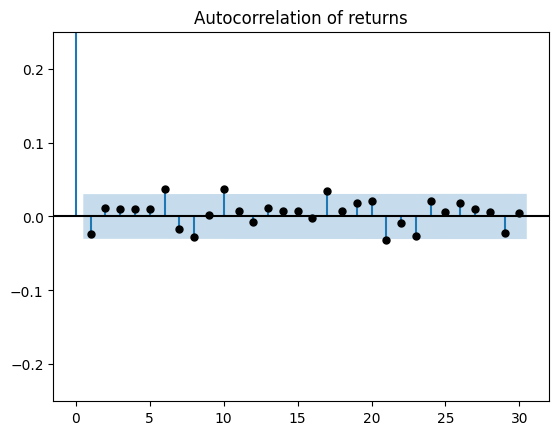

In [14]:
btc = yf.download("BTC-USD", period = "max", interval = "1d")
prices = btc["Close"] 
returns = np.log(prices).diff() 
returns = returns.dropna()

fig, ax = plt.subplots()
plot_acf(returns, lags=30, ax=ax, color= "black")

ax.set_title("Autocorrelation of returns")
ax.set_ylim(-0.25,0.25)

plt.show()

If there were temporal dependence, we would expect the correlation to decay gradually as the number of lags increases. However, what we observe is that **there is no clear difference between the first lags and the later ones**. We can therefore conclude that the linear autocorrelation of returns is low enough to be considered noise, which is unsurprising since most financial assets follow this same pattern.

> Since the first lag used to calculate autocorrelation is zero, it is normal that the first value spikes at 1, because any distribution is perfectly correlated with itself.

### 7.2 Autocorrelation of Squared Returns

If we now perform the same analysis on the **squared returns**, the conclusions change. By squaring the returns, large negative and positive moves are treated equally and do not cancel each other out. This provides a measure of how likely returns are to deviate from the mean, that is, **a measure of volatility**.

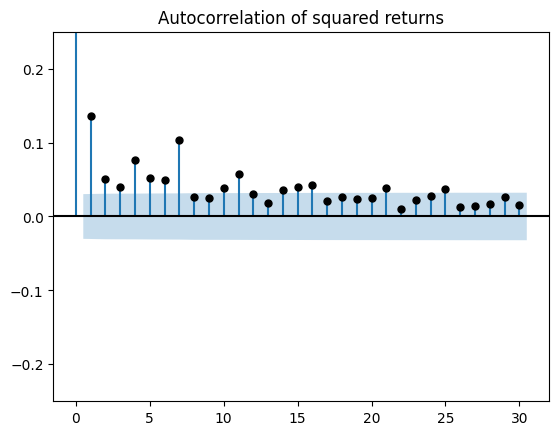

In [15]:
returns_SQ = returns**2

fig, ax = plt.subplots()
plot_acf(returns_SQ, lags=30, ax=ax, color= "black")

ax.set_title("Autocorrelation of squared returns")
ax.set_ylim(-0.25,0.25)

plt.show()

It is clear that extreme movements persist over time: the current value of squared returns depends strongly on the first lags, and this dependence decays roughly exponentially as the interval between the current observation and the i-th lag increases.

We can thus conclude that, although the autocorrelation of raw returns is low, **the autocorrelation of squared returns is significant**. This indicates that, while the market quickly “forgets” the direction of price movements, it remembers their intensity. This memory is precisely what leads to the formation of volatility clustering, as discussed throughout the analysis.


## 8. Scaling Behavior

Finally, since we know that **volatility is not constant over time**, we examine how it scales across different time horizons.


### 8.1 Hurst Exponent for Returns

We have seen that the time scale affects excess kurtosis and, consequently, the volatility of the distribution. Now, we need to check whether this volatility scales with the time horizon used to measure the asset, following the **volatility scaling law**, which states that the standard deviation $σ(Δt)$ should scale as the square root of time:

$$σ(Δt) ∝ (Δt)^H$$

where H ≈ 0.5 is the Hurst exponent.

If H ≠ 0.5, this would provide evidence of **long-term memory or a non-trivial structure**, explaining why returns cannot be considered i.i.d. and why volatility clustering is observed.

We use log-log plot of $\log(σ)$ vs $\log(Δt)$ to obtain the Hurst exponent as the slope of the line: 

$$\log(\sigma) = H \log(\Delta t) + cte$$


>If we only use daily, weekly, and monthly returns, the linear regression will not be very accurate. Therefore, we use a moving window via the rolling function, allowing us to choose the number and range of time horizons arbitrarily.

Hurst coefficient: 0.520
R: 0.9997


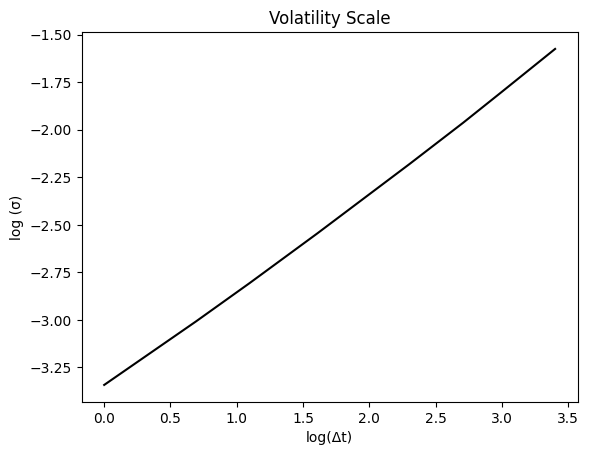

In [16]:
horizons = [1,2,3,5,10,15,20,30] #time horizons in days
sigmas = {t: returns.rolling(t).sum().std() for t in horizons} 
sigmas = list(sigmas.values())

log_horizons = np.log(horizons)
log_sigmas = np.log(sigmas)

log_horizons = log_horizons.tolist()
log_sigmas = log_sigmas.flatten().tolist()

fig, ax = plt.subplots()
ax.plot(log_horizons, log_sigmas, color="black")
ax.set_title("Volatility Scale")
ax.set_xlabel("log(Δt)")
ax.set_ylabel("log (σ)")

result = linregress(log_horizons, log_sigmas) 

print(f"Hurst coefficient: {result.slope:.3f}")
print(f"R: {result.rvalue:.4f}")


We observe that the Hurst exponent is close enough to 0.5 to once again consider that **returns follow a diffusive process**, which is unsurprising given the near-zero autocorrelation of returns. The asset shows a slight persistence, but it is so small that it can be treated as statistical noise.

### 8.2 Hurst Exponent for Absolute Returns

On the other hand, persistence becomes evident when analyzing the **absolute returns**.

> We chose absolute values instead of squared returns to maintain robustness against outliers.

Hurst coefficient: 0.740
R: 0.9989


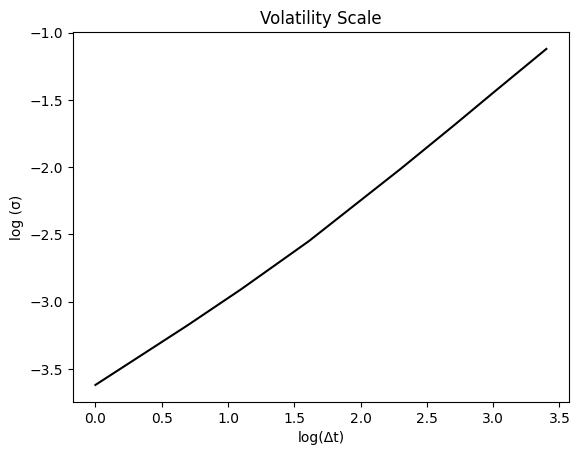

In [17]:
returns_abs = np.abs(returns) 
horizons = [1,2,3,5,10,15,20,30] 
sigmas = {t: returns_abs.rolling(t).sum().std() for t in horizons} 
sigmas = list(sigmas.values())

log_horizons = np.log(horizons)
log_sigmas = np.log(sigmas)

log_horizons = log_horizons.tolist()
log_sigmas = log_sigmas.flatten().tolist()

fig, ax = plt.subplots()
ax.plot(log_horizons, log_sigmas, color="black")
ax.set_title("Volatility Scale")
ax.set_xlabel("log(Δt)")
ax.set_ylabel("log (σ)")

result = linregress(log_horizons, log_sigmas) 
print(f"Hurst coefficient: {result.slope:.3f}")
print(f"R: {result.rvalue:.4f}")


In this case, the Hurst exponent is considerably higher than the previous 0.5, providing empirical evidence of **long-term memory** in our distribution. This indicates that volatility persists over time.

This demonstrates that, although we can treat returns as approximately i.i.d. and therefore cannot predict a specific direction we can anticipate the intensity of the movements, reflecting the clustering of high volatility periods.

## 9. Summary of Empirical Findings and Implications

In this study, we conducted a thorough statistical analysis of Bitcoin log-returns over the available historical period. Our main empirical findings are:

- **Non-Gaussianity and Heavy Tails**: Returns are leptokurtic, with a high excess kurtosis for daily data, indicating that extreme events occur more frequently than predicted by a normal distribution. The tails are heavy but do not strictly follow a power-law.

- **Volatility Clustering**: While raw returns exhibit negligible autocorrelation, squared and absolute returns show significant temporal dependence, confirming the presence of volatility clustering.

- **Scaling Behavior**: The Hurst exponent for raw returns is close to 0.5, consistent with a diffusive, approximately i.i.d. process, whereas the Hurst exponent for absolute returns is significantly higher, providing empirical evidence of long-term memory in volatility.

- **Temporal Aggregation Effects**: Increasing the time horizon reduces excess kurtosis, demonstrating the smoothing effect predicted by the Central Limit Theorem, though daily returns clearly deviate from Gaussian assumptions.

### 9.1 Implications

These results highlight key characteristics of real financial time series: returns are not perfectly random, extreme events are more likely than Gaussian models suggest, and volatility exhibits persistence. This has direct consequences for risk management, derivative pricing, and quantitative modeling, as classical Gaussian-based models may underestimate extreme movements and volatility dynamics.



## 10. Discussion of Limitations and Potential Extensions

### Limitations:

- **Data frequency and sampling**: Using only daily returns may overlook intra-day dynamics and microstructure effects.

- **Model simplifications**: Heavy-tail analysis relied on simple linear regressions in log-log space and extreme percentiles (e.g., 99.5th) are sensitive to sample size.

- **Univariate focus**: This analysis considered Bitcoin in isolation so correlations with other assets or market factors were not examined.

- **Linear methods**: Autocorrelation and Hurst analyses focus on linear dependencies and may miss non-linear or more complex temporal structures.

### Potential Extensions:

- **Higher-frequency data analysis**: Explore intraday returns to capture finer volatility patterns.

- **Multivariate approaches**: Study correlations with other cryptocurrencies or financial indices.

- **GARCH or stochastic volatility modeling**: Fit models that explicitly account for volatility clustering and heteroscedasticity.

- **Tail risk modeling**: Employ more sophisticated extreme-value theory methods to better capture rare events.

- **Non-linear dynamics**: Use machine learning or econophysical models to capture complex dependencies beyond standard linear measures.



## 11. References

- Mantegna, R. N., & Stanley, H. E. (2000). *An Introduction to Econophysics: Correlations and Complexity in Finance. Cambridge University Press.*

- MIT OpenCourseWare. *Mathematics in Applications to Finance*. https://ocw.mit.edu

- Yahoo Finance / yfinance documentation. https://finance.yahoo.com/
